## 1. Setup môi trường và DataSet

In [279]:
import pandas as pd
import numpy as np

In [280]:
df = pd.read_csv('medical_insurance.csv')

In [281]:
print("=== TỔNG QUAN DATASET ===")
print(f"Kích thước dfset: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"\nCác columns: {list(df.columns)}")

print("\n=== 5 DÒNG ĐẦU TIÊN ===")
df.head()

=== TỔNG QUAN DATASET ===
Kích thước dfset: 2772 dòng × 7 cột

Các columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

=== 5 DÒNG ĐẦU TIÊN ===


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [282]:
print("Tổng số ô thiếu:", df.isnull().sum().sum())

Tổng số ô thiếu: 0


## 2. Trực quan hóa dữ liệu

### 2.1  Phân phối chi phí (charges)

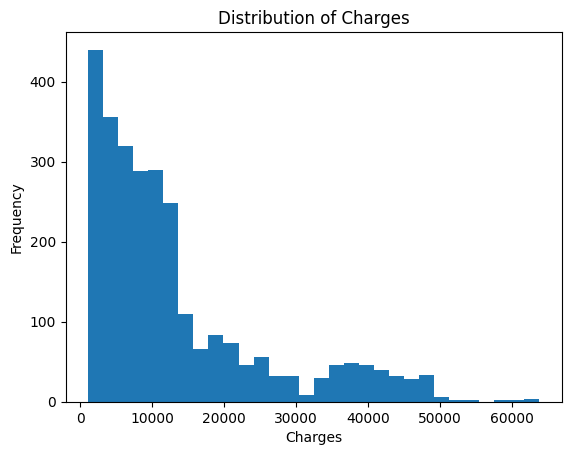

In [283]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

#### lệch phải rất mạnh → người hút thuốc thường kéo chi phí lên cao

### 2.2 Age vs Charges

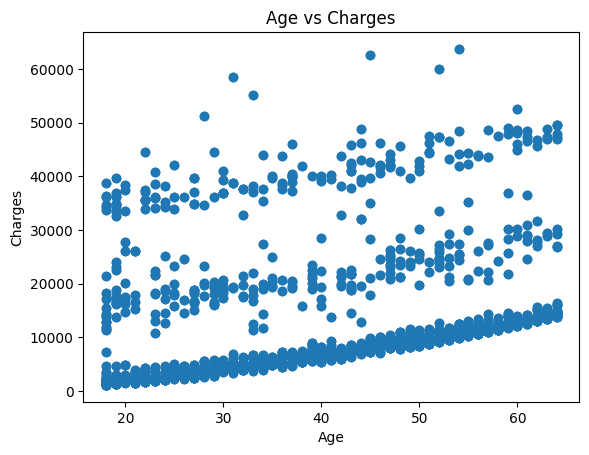

In [284]:
plt.figure()
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

### 2.3. BMI vs Charges

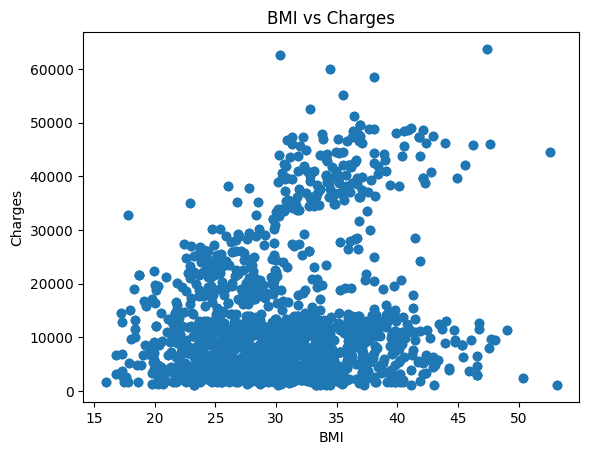

In [285]:
plt.figure()
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

### 2.4. Smoker vs Charges

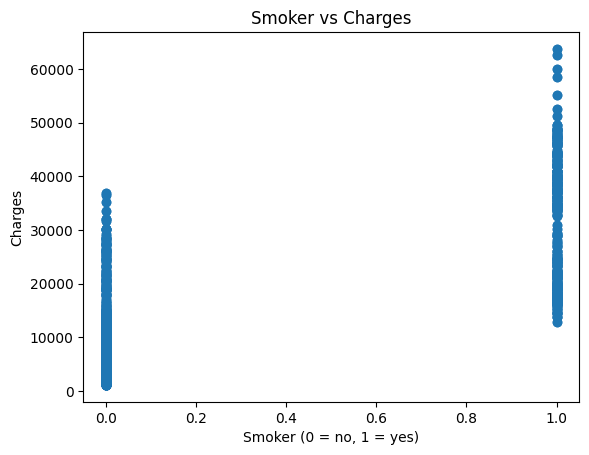

In [286]:
# chuyển smoker thành số để plot
df['smoker_num'] = df['smoker'].map({'yes':1, 'no':0})

plt.figure()
plt.scatter(df['smoker_num'], df['charges'])
plt.title("Smoker vs Charges")
plt.xlabel("Smoker (0 = no, 1 = yes)")
plt.ylabel("Charges")
plt.show()

### 2.5. Children vs Charges


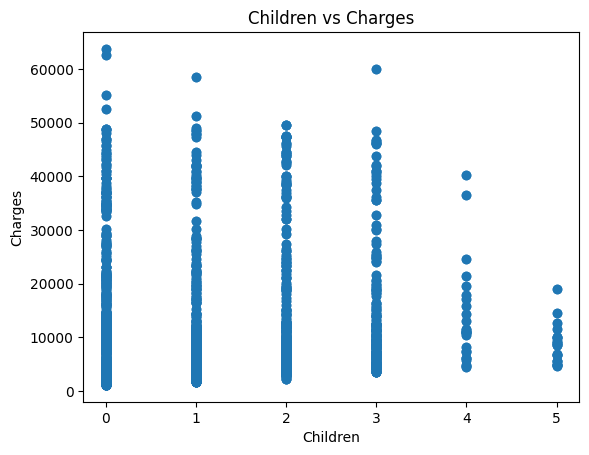

In [287]:
plt.figure()
plt.scatter(df['children'], df['charges'])
plt.title("Children vs Charges")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

## 3 Split Data Train, Test và Val

In [288]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [289]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [290]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2217, 7)
Val: (277, 7)
Test: (278, 7)


## 4. Tiền xử lí dữ liệu

### tách Data thành 2 loại NUMERICAL và CATEGORICAL 

In [291]:
num_cols = ["age", "bmi", "children"]
cate_cols = ["sex", "smoker", "region"]

X_train_num = X_train[num_cols].copy()
X_val_num = X_val[num_cols].copy()
X_test_num = X_test[num_cols].copy()

X_train_cate = X_train[cate_cols].copy()
X_val_cate = X_val[cate_cols].copy()
X_test_cate = X_test[cate_cols].copy()

### Endcode Data Categorical 

In [292]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

X_train_cate_encoded = encoder.fit_transform(X_train_cate)
X_val_cate_encoded = encoder.transform(X_val_cate)
X_test_cate_encoded = encoder.transform(X_test_cate)

encoded_feature_names = encoder.get_feature_names_out(cate_cols)

print("Encoded categorical columns:")
print(encoded_feature_names)

Encoded categorical columns:
['sex_male' 'smoker_yes' 'region_northwest' 'region_southeast'
 'region_southwest']


### Scale Data Numerical 

In [293]:
class StandardScalerCustom:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        
    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [294]:
scaler = StandardScalerCustom()

X_train_num_scaled = scaler.fit_transform(X_train_num.values)
X_val_num_scaled = scaler.transform(X_val_num.values)
X_test_num_scaled = scaler.transform(X_test_num.values)

### Gộp Data Numerical và Categorical lại sau tiền xử lí dữ liệu

In [295]:
X_train_num_scaled = pd.DataFrame(
    X_train_num_scaled, columns=num_cols, index=X_train.index
)

X_val_num_scaled = pd.DataFrame(
    X_val_num_scaled, columns=num_cols, index=X_val.index
)

X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled, columns=num_cols, index=X_test.index
)

X_train_cate_encoded = pd.DataFrame(
    X_train_cate_encoded, columns=encoded_feature_names, index=X_train.index
)

X_val_cate_encoded = pd.DataFrame(
    X_val_cate_encoded, columns=encoded_feature_names, index=X_val.index
)

X_test_cate_encoded = pd.DataFrame(
    X_test_cate_encoded, columns=encoded_feature_names, index=X_test.index
)

In [296]:
X_train = pd.concat([X_train_num_scaled, X_train_cate_encoded], axis=1)
X_val = pd.concat([X_val_num_scaled, X_val_cate_encoded], axis=1)
X_test = pd.concat([X_test_num_scaled, X_test_cate_encoded], axis=1)

In [297]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nMean của X_train sau scale:")
print(np.mean(X_train, axis=0))

print("\nStd của X_train sau scale:")
print(np.std(X_train, axis=0))

X_train shape: (2217, 8)
X_val shape: (277, 8)
X_test shape: (278, 8)
y_train shape: (2217,)
y_val shape: (277,)
y_test shape: (278,)

Mean của X_train sau scale:
age                 1.121741e-16
bmi                -4.711312e-16
children            3.845969e-17
sex_male            5.105999e-01
smoker_yes          2.092918e-01
region_northwest    2.426703e-01
region_southeast    2.715381e-01
region_southwest    2.462788e-01
dtype: float64

Std của X_train sau scale:
age                 1.000000
bmi                 1.000000
children            1.000000
sex_male            0.499888
smoker_yes          0.406803
region_northwest    0.428697
region_southeast    0.444753
region_southwest    0.430843
dtype: float64


## 5. Build Model Lasso Regression

In [298]:
# 1. HÀM DỰ ĐOÁN
def predict(X, w, b):
    return np.dot(X, w) + b

# 2. HÀM LOSS CHO LASSO
# Loss = MSE + lambda * sum(|w|)

def compute_loss_lasso(X, y, w, b, lambda_):
    m = X.shape[0]
    y_hat = predict(X, w, b)

    mse = (1 / m) * np.sum((y_hat - y) ** 2)
    l1_penalty = lambda_ * np.sum(np.abs(w))

    return mse + l1_penalty


# 3. HÀM TÍNH GRADIENT

def compute_gradient_lasso(X, y, w, b, lambda_):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y

    dw_mse = (2 / m) * np.dot(X.T, error)
    db = (2 / m) * np.sum(error)

    # subgradient của |w|
    dw_l1 = lambda_ * np.sign(w)

    dw = dw_mse + dw_l1
    return dw, db


# 4. HÀM UPDATE THAM SỐ

def update_weights(w, b, dw, db, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b


# 5. HÀM TRAIN LASSO

def train_lasso(X, y, learning_rate=0.01, epochs=1000, lambda_=0.1, verbose=True):
    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0.0

    loss_history = []

    for epoch in range(epochs):
        dw, db = compute_gradient_lasso(X, y, w, b, lambda_)
        w, b = update_weights(w, b, dw, db, learning_rate)

        loss = compute_loss_lasso(X, y, w, b, lambda_)
        loss_history.append(loss)

        if verbose and epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss:.4f}")

    return w, b, loss_history


# 6. CÁC HÀM ĐÁNH GIÁ

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_rmse(y_true, y_pred):
    return np.sqrt(compute_mse(y_true, y_pred))

def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)





In [299]:
# 7. TUNE LAMBDA BẰNG VALIDATION SET

# lambda_candidates = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
lambda_candidates = [0.1, 1, 5, 10, 50, 100]

best_lambda = None
best_val_mse = float("inf")
best_w = None
best_b = None
best_loss_history = None

print("=== Tune lambda on validation set ===")

for lam in lambda_candidates:
    w_tmp, b_tmp, loss_hist_tmp = train_lasso(
        X_train,
        y_train,
        learning_rate=0.01,
        epochs=1000,
        lambda_=lam,
        verbose=False
    )

    y_val_pred_tmp = predict(X_val, w_tmp, b_tmp)
    val_mse_tmp = compute_mse(y_val, y_val_pred_tmp)

    print(f"lambda = {lam:<6} | Validation MSE = {val_mse_tmp:.4f}")

    if val_mse_tmp < best_val_mse:
        best_val_mse = val_mse_tmp
        best_lambda = lam
        best_w = w_tmp.copy()
        best_b = b_tmp
        best_loss_history = loss_hist_tmp.copy()

print("\nBest lambda:", best_lambda)
print("Best validation MSE:", best_val_mse)

=== Tune lambda on validation set ===
lambda = 0.1    | Validation MSE = 39631749.4849
lambda = 1      | Validation MSE = 39629597.6206
lambda = 5      | Validation MSE = 39620471.2192
lambda = 10     | Validation MSE = 39610119.4874
lambda = 50     | Validation MSE = 39563943.7719
lambda = 100    | Validation MSE = 39545324.5624

Best lambda: 100
Best validation MSE: 39545324.56240797


### VẼ LOSS CỦA MODEL TỐT NHẤT

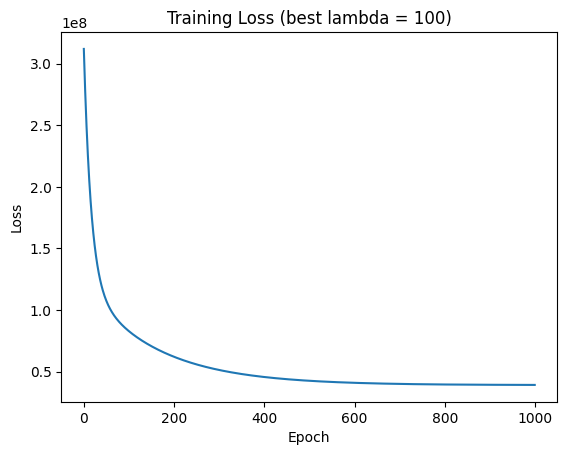

In [300]:
plt.figure()
plt.plot(best_loss_history)
plt.title(f"Training Loss (best lambda = {best_lambda})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


### DỰ ĐOÁN TRÊN TRAIN / VAL / TEST

In [301]:
y_train_pred = predict(X_train, best_w, best_b)
y_val_pred = predict(X_val, best_w, best_b)
y_test_pred = predict(X_test, best_w, best_b)


# 10. ĐÁNH GIÁ MÔ HÌNH

print("\n=== Final Evaluation ===")

print("\n[TRAIN]")
print("MSE :", compute_mse(y_train, y_train_pred))
print("RMSE:", compute_rmse(y_train, y_train_pred))
print("MAE :", compute_mae(y_train, y_train_pred))
print("R2  :", compute_r2(y_train, y_train_pred))

print("\n[VALIDATION]")
print("MSE :", compute_mse(y_val, y_val_pred))
print("RMSE:", compute_rmse(y_val, y_val_pred))
print("MAE :", compute_mae(y_val, y_val_pred))
print("R2  :", compute_r2(y_val, y_val_pred))

print("\n[TEST]")
print("MSE :", compute_mse(y_test, y_test_pred))
print("RMSE:", compute_rmse(y_test, y_test_pred))
print("MAE :", compute_mae(y_test, y_test_pred))
print("R2  :", compute_r2(y_test, y_test_pred))


=== Final Evaluation ===

[TRAIN]
MSE : 36358873.06551349
RMSE: 6029.831926804717
MAE : 4220.928957042637
R2  : 0.751108010718977

[VALIDATION]
MSE : 39545324.56240797
RMSE: 6288.507339775312
MAE : 4119.894441319742
R2  : 0.7039636159873361

[TEST]
MSE : 41363566.379688896
RMSE: 6431.451343179772
MAE : 4365.76326842494
R2  : 0.7613272390777356


### Xem hệ số của từng feature

In [302]:
feature_names = X_train.columns.tolist()

for name, weight in zip(feature_names, best_w):
    print(f"{name}: {weight:.4f}")

age: 3496.1634
bmi: 1852.5234
children: 504.8651
sex_male: -0.8344
smoker_yes: 22717.3275
region_northwest: 85.7154
region_southeast: -122.6506
region_southwest: -193.8208


##### -- Mô hình cho thấy smoker_yes, age, bmi là các yếu tố ảnh hưởng mạnh nhất đến chi phí, trong khi các biến như sex_male và region_* có trọng số rất nhỏ, gần như không đáng kể.
##### -- Điều này chứng tỏ Lasso đã hoạt động hiệu quả trong việc giữ lại feature quan trọng và loại bỏ các feature yếu.

## Xuất file model pkl

In [303]:
import pickle

model_data = {
    "w": best_w,
    "b": best_b,
    "lambda": best_lambda,
    "feature_names": feature_names,
    "scaler_mean": scaler.mean,
    "scaler_std": scaler.std,
    "encoder_categories": encoder.categories_
}

with open("lasso_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Đã lưu model vào file lasso_model.pkl")

Đã lưu model vào file lasso_model.pkl


In [304]:
with open("lasso_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print(loaded_model.keys())

dict_keys(['w', 'b', 'lambda', 'feature_names', 'scaler_mean', 'scaler_std', 'encoder_categories'])


In [305]:
w_loaded = loaded_model["w"]
b_loaded = loaded_model["b"]
lambda_loaded = loaded_model["lambda"]
feature_names_loaded = loaded_model["feature_names"]

## 6. So sánh hiệu suất modle với SKLearn

## UI GRADIO

In [ ]:
import gradio as gr
import pandas as pd
import pickle
import numpy as np

# =========================================================
# 1. LOAD MODEL
# =========================================================
with open("lasso_model.pkl", "rb") as f:
    pipe = pickle.load(f)

# =========================================================
# 2. HÀM PREPROCESS CHO INPUT MỚI
# =========================================================
def preprocess_input(input_df, model_params):
    df = input_df.copy()

    feature_names = model_params["feature_names"]
    scaler_mean = np.array(model_params["scaler_mean"], dtype=float)
    scaler_std = np.array(model_params["scaler_std"], dtype=float)

    scaler_std[scaler_std == 0] = 1

    # 1. Numerical features
    numerical_data = df[["age", "bmi", "children"]].values.astype(float)
    numerical_scaled = (numerical_data - scaler_mean) / scaler_std

    # 2. Categorical features (manual one-hot giống lúc train)
    sex_male = (df["sex"] == "male").astype(int).values.reshape(-1, 1)
    smoker_yes = (df["smoker"] == "yes").astype(int).values.reshape(-1, 1)
    region_northwest = (df["region"] == "northwest").astype(int).values.reshape(-1, 1)
    region_southeast = (df["region"] == "southeast").astype(int).values.reshape(-1, 1)
    region_southwest = (df["region"] == "southwest").astype(int).values.reshape(-1, 1)

    # 3. Gộp lại đúng thứ tự feature
    processed_data = np.hstack([
        numerical_scaled,
        sex_male,
        smoker_yes,
        region_northwest,
        region_southeast,
        region_southwest
    ])

    # Nếu muốn chắc chắn tuyệt đối đúng thứ tự feature_names
    current_feature_order = [
        "age", "bmi", "children",
        "sex_male", "smoker_yes",
        "region_northwest", "region_southeast", "region_southwest"
    ]

    feature_index = [current_feature_order.index(col) for col in feature_names]
    processed_data = processed_data[:, feature_index]

    return processed_data

# =========================================================
# 3. HÀM DỰ ĐOÁN 1 NGƯỜI
# =========================================================
def predict_single(age, sex, bmi, children, smoker, region):
    row = {
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region
    }

    df = pd.DataFrame([row])

    processed_data = preprocess_input(df, pipe)

    y_pred = np.dot(processed_data, pipe["w"]) + pipe["b"]

    pred = float(y_pred[0])
    return f"${pred:,.2f}"

def classify_cost(pred):
    if pred < 5000:
        return "Low"
    elif pred < 15000:
        return "Medium"
    elif pred < 30000:
        return "High"
    else:
        return "Very High"

# =========================================================
# 4. GRADIO UI
# =========================================================

# custom_css = """
# .gradio-container {
#     max-width: 900px !important;
#     margin: auto;
# }
# button {
#     font-size: 16px !important;
#     font-weight: 600 !important;
# }
# """

custom_css = """
body {
    background: linear-gradient(135deg, #0f172a, #1e293b);
}
"""

with gr.Blocks(title="Insurance Cost Predictor",css=custom_css ,theme = gr.themes.Soft(primary_hue="indigo")) as demo:
    gr.Markdown(
        """
        ## Dự đoán chi phí bảo hiểm y tế
        Nhập thông tin cá nhân.  
        Mô hình sử dụng **Lasso Regression thủ công**.
        """
    )

    with gr.Tab("Dự đoán 1 người"):
        with gr.Row():
            age = gr.Slider(18, 64, value=25, step=1, label="Age")
            sex = gr.Dropdown(["female", "male"], label="Sex", value="female")
            bmi = gr.Slider(15.0, 50.0, value=28.5, step=0.1, label="BMI")

        with gr.Row():
            children = gr.Slider(0, 5, value=0, step=1, label="Children")
            smoker = gr.Dropdown(["no", "yes"], label="Smoker", value="no")
            region = gr.Dropdown(
                ["northeast", "northwest", "southeast", "southwest"],
                label="Region",
                value="southeast"
            )

        btn = gr.Button("Dự đoán")
        out_single = gr.Markdown(label="Insurance charge dự đoán")

        btn.click(
            predict_single,
            inputs=[age, sex, bmi, children, smoker, region],
            outputs=out_single,
        )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7868

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
